
# Módulo 3 — Otimizadores modernos em Deep Learning

> **Tema:** SGD + Momentum/Nesterov, Adam/RMSProp/AdamW, weight decay acoplado vs desacoplado e critérios práticos de escolha.  
> **Objetivo didático:** ao final, você deve saber **como cada otimizador atualiza os pesos**, **quando usar cada um** e **como evitar escolhas que parecem boas no treino mas pioram a generalização**.

---

## Roteiro da aula

1. Revisão rápida: gradiente e atualização de parâmetros  
2. SGD, Momentum e Nesterov (intuição física + prática)  
3. RMSProp, Adam e AdamW (por que AdamW costuma ser preferível)  
4. Weight decay acoplado vs desacoplado (demonstração numérica)  
5. Quando escolher cada otimizador (visão prática de projeto)



## 0) Setup

> Este notebook usa apenas bibliotecas padrão de ciência de dados e **PyTorch**.  
> Se rodar em CPU, os exemplos ainda funcionam (podem ficar um pouco mais lentos).


In [6]:

# =========================
# Setup e utilitários
# =========================
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Reprodutibilidade (didática)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda



## 1) Revisão curta: o que muda de um otimizador para outro?

Todos minimizam uma função de perda \(L(\theta)\), mas diferem em **como** atualizam os parâmetros:

\[
$\theta_{t+1} = \theta_t - \Delta_t$
\]

- No **SGD**, $\Delta_t = \eta g_t$, onde \($g_t = \nabla$ L($\theta_t$)\)
- Em **Momentum/Nesterov**, há uma velocidade acumulada.
- Em **RMSProp/Adam**, usa-se escala adaptativa por parâmetro.
- Em **AdamW**, separa-se o efeito de regularização (weight decay) do gradiente adaptativo.



## 2) SGD, Momentum e Nesterov — intuição + visualização geométrica

Vamos usar uma função quadrática 2D (tipo “vale”) para visualizar trajetórias de otimização.

### Intuição física:
- **SGD**: “andar seguindo a ladeira local”.
- **Momentum**: “bola com inércia”; ganha velocidade na direção consistente e suaviza oscilações.
- **Nesterov**: olha “um passo à frente” antes de corrigir, reduzindo overshoot.


In [7]:

# =====================================
# Função quadrática 2D para visualização
# =====================================
# f(x, y) = 0.5 * (a*x^2 + b*y^2)
# Se b >> a, temos um vale estreito -> cenário clássico de oscilação.
a, b = 1.0, 20.0

def grad_f(theta):
    x, y = theta
    return np.array([a*x, b*y], dtype=np.float64)

def f(theta):
    x, y = theta
    return 0.5*(a*x*x + b*y*y)

def run_optimizer(kind="sgd", lr=0.08, mu=0.9, steps=80, theta0=np.array([6.0, 6.0], dtype=np.float64)):
    theta = theta0.copy()
    v = np.zeros_like(theta)
    path = [theta.copy()]
    losses = [f(theta)]

    for _ in range(steps):
        if kind == "sgd":
            g = grad_f(theta)
            theta = theta - lr*g

        elif kind == "momentum":
            g = grad_f(theta)
            v = mu*v - lr*g
            theta = theta + v

        elif kind == "nesterov":
            # Look-ahead gradient (***Investigar a equacao Nesterov)
            g = grad_f(theta + mu*v)
            v = mu*v - lr*g
            theta = theta + v
        else:
            raise ValueError("kind inválido")

        path.append(theta.copy())
        losses.append(f(theta))
    return np.array(path), np.array(losses)

path_sgd, loss_sgd = run_optimizer("sgd", lr=0.08, steps=80)
path_mom, loss_mom = run_optimizer("momentum", lr=0.08, mu=0.9, steps=80)
path_nag, loss_nag = run_optimizer("nesterov", lr=0.08, mu=0.9, steps=80)

print(f"Loss final - SGD:      {loss_sgd[-1]:.6f}")
print(f"Loss final - Momentum: {loss_mom[-1]:.6f}")
print(f"Loss final - Nesterov: {loss_nag[-1]:.6f}")


Loss final - SGD:      0.000029
Loss final - Momentum: 0.096593
Loss final - Nesterov: 1433575358356463251507298435072.000000


Fazer exercício de correção do Nesterov

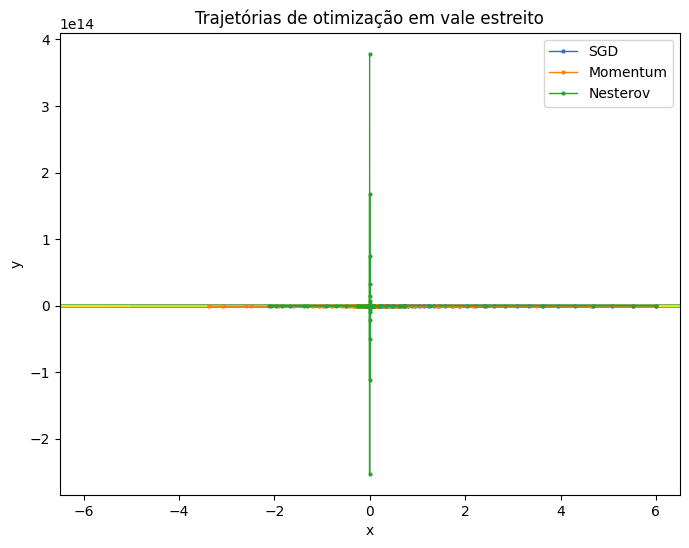

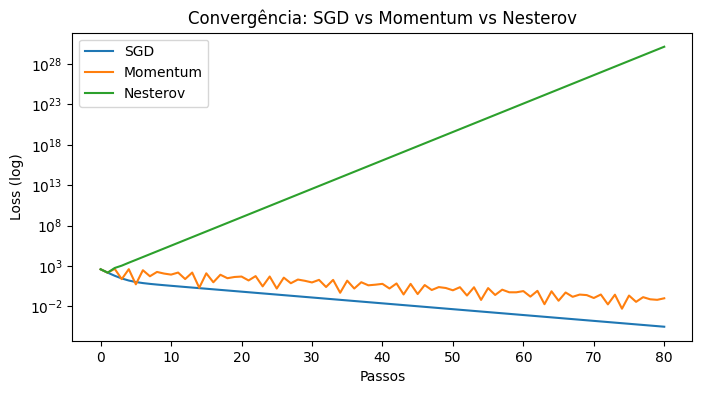

In [8]:

# =====================================
# Gráficos: superfície + trajetórias
# =====================================
x = np.linspace(-6.5, 6.5, 300)
y = np.linspace(-6.5, 6.5, 300)
X, Y = np.meshgrid(x, y)
Z = 0.5*(a*X**2 + b*Y**2)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=35)
plt.plot(path_sgd[:,0], path_sgd[:,1], marker='o', markersize=2, linewidth=1, label='SGD')
plt.plot(path_mom[:,0], path_mom[:,1], marker='o', markersize=2, linewidth=1, label='Momentum')
plt.plot(path_nag[:,0], path_nag[:,1], marker='o', markersize=2, linewidth=1, label='Nesterov')
plt.title("Trajetórias de otimização em vale estreito")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(loss_sgd, label='SGD')
plt.plot(loss_mom, label='Momentum')
plt.plot(loss_nag, label='Nesterov')
plt.yscale('log')
plt.xlabel("Passos")
plt.ylabel("Loss (log)")
plt.title("Convergência: SGD vs Momentum vs Nesterov")
plt.legend()
plt.show()



### Leitura didática dos resultados
- **SGD** tende a oscilar mais no eixo de alta curvatura (vale estreito).
- **Momentum** acelera convergência ao “acumular direção”.
- **Nesterov** frequentemente corrige melhor o passo e pode convergir com menos zig-zag.

> Em problemas reais (CNNs/Transformers), esse efeito aparece como treino mais estável e rápido com Momentum/Nesterov comparado ao SGD puro.



## 3) RMSProp, Adam e AdamW

### Ideia central
Em muitos modelos, diferentes parâmetros têm escalas de gradiente bem distintas.  
Otimizadores adaptativos ajustam o passo **por parâmetro**:

- **RMSProp**: usa média móvel de \(g^2\) para normalizar o passo.
- **Adam**: combina Momentum (1º momento) + RMSProp (2º momento).
- **AdamW**: mesma base do Adam, mas com **weight decay desacoplado**.

### Por que AdamW costuma ser preferível ao Adam clássico?
No Adam clássico, “L2” costuma entrar acoplado ao gradiente, interagindo com a adaptação do passo por parâmetro.  
No **AdamW**, o encolhimento de pesos (weight decay) é aplicado **separadamente**, tornando a regularização mais previsível e geralmente melhor para generalização.


In [9]:
from ipywidgets import interact, FloatSlider, IntSlider, ToggleButtons

# Experimento 2: Por que AdamW? (Decoupled Weight Decay)

def visualize_adam_vs_adamw(decay_strength=0.1):
    steps = 50
    lr = 0.01

    # Cenário: Queremos otimizar f(x) = 0 (apenas o weight decay atua)
    # Inicializamos longe de zero
    p_adam = torch.nn.Parameter(torch.tensor([10.0]))
    p_adamw = torch.nn.Parameter(torch.tensor([10.0]))

    # Configurar otimizadores com o MESMO weight_decay
    opt_adam = torch.optim.Adam([p_adam], lr=lr, weight_decay=decay_strength)
    opt_adamw = torch.optim.AdamW([p_adamw], lr=lr, weight_decay=decay_strength)

    hist_adam = []
    hist_adamw = []

    for _ in range(steps):
        # Loss Zero (queremos ver apenas o efeito do decay)
        # Em um cenário real, haveria gradients, mas aqui isolamos o decay
        opt_adam.zero_grad()
        loss_adam = 0.0 * p_adam # Dummy loss
        loss_adam.backward()
        opt_adam.step()
        hist_adam.append(p_adam.item())

        opt_adamw.zero_grad()
        loss_adamw = 0.0 * p_adamw
        loss_adamw.backward()
        opt_adamw.step()
        hist_adamw.append(p_adamw.item())

    plt.figure(figsize=(10, 6))
    plt.plot(hist_adam, label='Adam (L2 Regularization)', marker='o')
    plt.plot(hist_adamw, label='AdamW (Decoupled Decay)', marker='s')
    plt.title("Eficácia da Regularização: Adam vs AdamW")
    plt.ylabel("Valor do Peso (deve ir para zero)")
    plt.xlabel("Passos")
    plt.axhline(0, color='black', linestyle='--')
    plt.legend()
    plt.grid(True)
    plt.show()

print("O AdamW aplica o decaimento DIRETAMENTE no peso, não no gradiente.")
print("Isso garante que a regularização funcione mesmo quando o gradiente adaptativo do Adam é estranho.")
interact(visualize_adam_vs_adamw,
         decay_strength=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.1, description='Weight Decay'));

O AdamW aplica o decaimento DIRETAMENTE no peso, não no gradiente.
Isso garante que a regularização funcione mesmo quando o gradiente adaptativo do Adam é estranho.


interactive(children=(FloatSlider(value=0.1, description='Weight Decay', max=1.0, step=0.05), Output()), _dom_…

No Adam clássico, a regularização L2 é somada ao gradiente antes da adaptação. Isso faz com que pesos grandes sejam punidos pouco se a variância for alta. O AdamW separa a punição, garantindo que o peso diminua corretamente.


## 4) Experimento prático: comparar otimizadores em uma MLP (dataset `make_moons`)

Vamos treinar a mesma arquitetura mudando apenas o otimizador.


In [10]:

# =====================================
# Dataset sintético: moons
# =====================================
X, y = make_moons(n_samples=3000, noise=0.25, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)

print("Treino:", X_train_t.shape, "Val:", X_val_t.shape)


Treino: torch.Size([2100, 2]) Val: torch.Size([900, 2])


In [11]:

# =====================================
# Modelo base (mesma arquitetura para todos)
# =====================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def evaluate(model, loader):
    model.eval()
    ys, ps, losses = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            losses.append(loss.item())

            prob = torch.sigmoid(logits)
            ys.append(yb.cpu().numpy())
            ps.append(prob.cpu().numpy())

    y_true = np.vstack(ys).ravel()
    y_prob = np.vstack(ps).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return {"loss": float(np.mean(losses)), "acc": acc, "f1": f1, "auc": auc}


In [12]:

# =====================================
# Treino genérico para comparar otimizadores
# =====================================
def train_with_optimizer(optimizer_name="SGD", lr=1e-2, weight_decay=0.0, epochs=40):
    torch.manual_seed(SEED)
    model = MLP().to(device)

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0, weight_decay=weight_decay)
    elif optimizer_name == "SGD+Momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=False, weight_decay=weight_decay)
    elif optimizer_name == "Nesterov":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    elif optimizer_name == "RMSProp":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.99, eps=1e-8, weight_decay=weight_decay)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=weight_decay)
    else:
        raise ValueError("Otimizador não suportado")

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "val_auc": []}

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auc"].append(val_metrics["auc"])

    return model, history


In [13]:

# =====================================
# Rodar comparação
# =====================================
configs = [
    ("SGD",           {"lr": 0.05, "weight_decay": 0.0}),
    ("SGD+Momentum",  {"lr": 0.03, "weight_decay": 0.0}),
    ("Nesterov",      {"lr": 0.03, "weight_decay": 0.0}),
    ("RMSProp",       {"lr": 0.005, "weight_decay": 0.0}),
    ("Adam",          {"lr": 0.003, "weight_decay": 1e-4}),
    ("AdamW",         {"lr": 0.003, "weight_decay": 1e-2}),
]

all_hist = {}
for name, kwargs in configs:
    _, h = train_with_optimizer(name, epochs=35, **kwargs)
    all_hist[name] = h
    print(f"{name:12s} | val_loss={h['val_loss'][-1]:.4f} | val_acc={h['val_acc'][-1]:.3f} | val_f1={h['val_f1'][-1]:.3f} | val_auc={h['val_auc'][-1]:.3f}")


SGD          | val_loss=0.1676 | val_acc=0.941 | val_f1=0.942 | val_auc=0.985
SGD+Momentum | val_loss=0.1806 | val_acc=0.930 | val_f1=0.933 | val_auc=0.986
Nesterov     | val_loss=0.1739 | val_acc=0.933 | val_f1=0.936 | val_auc=0.986
RMSProp      | val_loss=0.1672 | val_acc=0.941 | val_f1=0.943 | val_auc=0.985
Adam         | val_loss=0.1614 | val_acc=0.939 | val_f1=0.940 | val_auc=0.986
AdamW        | val_loss=0.1600 | val_acc=0.937 | val_f1=0.938 | val_auc=0.986


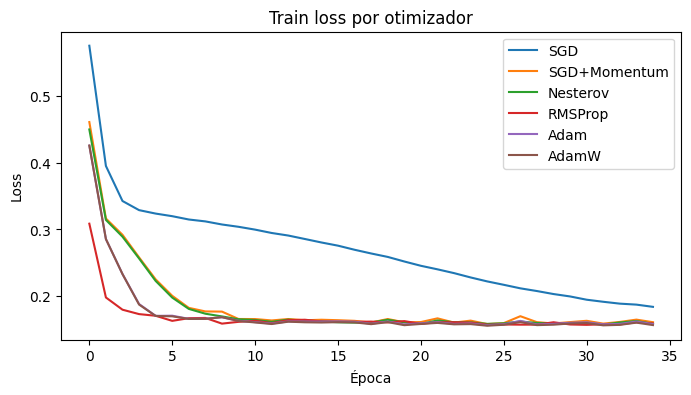

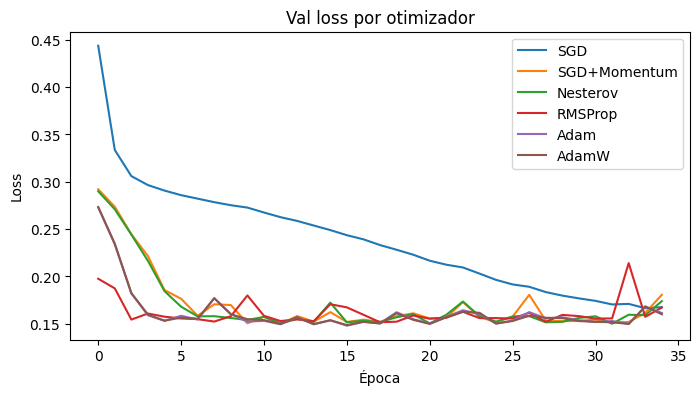

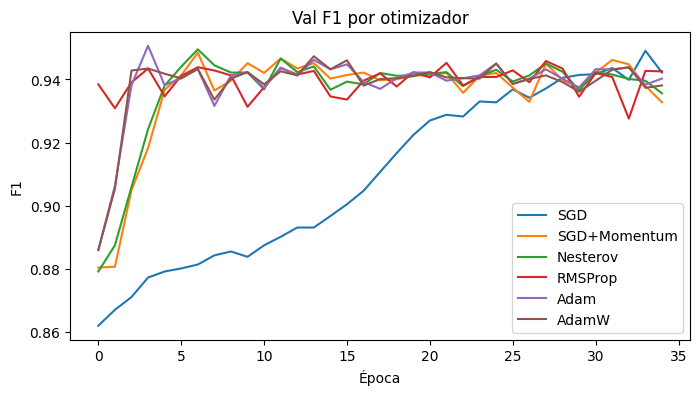

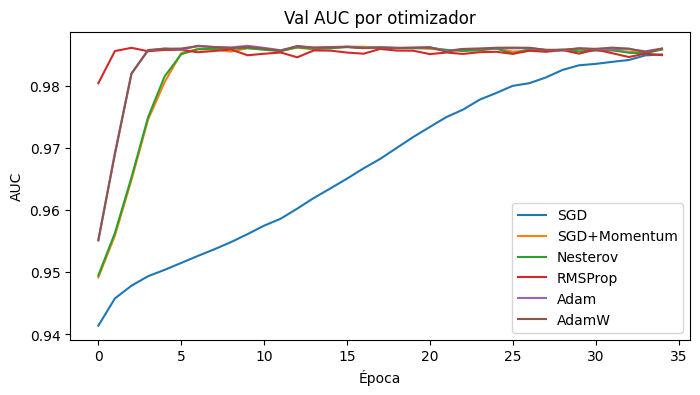

In [14]:

# =====================================
# Visualização de curvas
# =====================================
def plot_metric(histories, key, title, ylabel):
    plt.figure(figsize=(8,4))
    for name, h in histories.items():
        plt.plot(h[key], label=name)
    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_metric(all_hist, "train_loss", "Train loss por otimizador", "Loss")
plot_metric(all_hist, "val_loss",   "Val loss por otimizador", "Loss")
plot_metric(all_hist, "val_f1",     "Val F1 por otimizador",   "F1")
plot_metric(all_hist, "val_auc",    "Val AUC por otimizador",  "AUC")


Vamos criar uma superfície de custo "traiçoeira" (Função de Beale ou Rosenbrock) e colocar SGD, Momentum, RMSProp e Adam para competir. Isso mostra visualmente por que métodos adaptativos (Adam) são os favoritos para prototipagem rápida.

Mostra que o **SGD** sofre em vales (oscila), o **Momentum** ganha velocidade (mas pode passar do ponto), e o **Adam** navega direto para o alvo, ignorando a curvatura ruim.

In [15]:
# Experimento 1: A Corrida dos Otimizadores ---
# Este código cria um visualizador 2D para comparar trajetórias em tempo real.

import torch
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, SelectMultiple

def plot_optimizer_race(lr=0.01, steps=200):
    # 1. Superfície de Custo (Beale Function - Difícil, com platôs e picos)
    f = lambda x, y: (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

    # Grid para contorno
    x = np.linspace(-4.5, 4.5, 100)
    y = np.linspace(-4.5, 4.5, 100)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    # Ponto Inicial (Longe do mínimo)
    start_point = torch.tensor([-3.0, -3.0])

    # 2. Configurar Competidores
    optimizers = {
        'SGD': torch.optim.SGD,
        'SGD+Momentum': lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9),
        'RMSprop': torch.optim.RMSprop,
        'Adam': torch.optim.Adam
    }

    paths = {}
    colors = {'SGD': 'red', 'SGD+Momentum': 'blue', 'RMSprop': 'green', 'Adam': 'purple'}

    for name, opt_class in optimizers.items():
        # Reinicia parâmetro para cada otimizador
        param = torch.nn.Parameter(start_point.clone())

        # Instancia otimizador (alguns precisam de lambdas por causa dos args extras)
        if name == 'SGD+Momentum':
            opt = opt_class([param], lr)
        else:
            opt = opt_class([param], lr=lr)

        path = [param.detach().numpy().copy()]

        for _ in range(steps):
            opt.zero_grad()
            # Calcula Loss
            x_val, y_val = param[0], param[1]
            loss = (1.5 - x_val + x_val*y_val)**2 + \
                   (2.25 - x_val + x_val*y_val**2)**2 + \
                   (2.625 - x_val + x_val*y_val**3)**2
            loss.backward()
            opt.step()
            path.append(param.detach().numpy().copy())

        paths[name] = np.array(path)

    # 3. Visualização
    plt.figure(figsize=(12, 8))
    plt.contour(X, Y, Z, levels=np.logspace(0, 5, 35), cmap='jet', alpha=0.4)
    plt.plot(3, 0.5, 'k*', markersize=15, label='Mínimo Global') # Beale Min

    for name, path in paths.items():
        plt.plot(path[:, 0], path[:, 1], 'o-', label=name, color=colors[name], markersize=4, alpha=0.8, linewidth=1.5)
        # Marca o fim
        plt.plot(path[-1, 0], path[-1, 1], 'X', color=colors[name], markersize=10)

    plt.title(f"Corrida em Superfície Complexa (Beale Function) - LR: {lr}")
    plt.legend()
    plt.xlim(-4.5, 4.5); plt.ylim(-4.5, 4.5)
    plt.show()

print("O 'Adam' geralmente vence em terrenos complexos por adaptar o passo.")
print("O 'SGD' puro sofre para sair das áreas planas (platôs).")
interact(plot_optimizer_race,
         lr=FloatSlider(min=0.001, max=0.1, step=0.001, value=0.01, description='Learning Rate'),
         steps=IntSlider(min=50, max=500, step=50, value=200, description='Passos'));

O 'Adam' geralmente vence em terrenos complexos por adaptar o passo.
O 'SGD' puro sofre para sair das áreas planas (platôs).


interactive(children=(FloatSlider(value=0.01, description='Learning Rate', max=0.1, min=0.001, step=0.001), In…


### Observação didática importante
Não existe “melhor universal”. O que você verá na prática depende de:
- arquitetura (CNN, Transformer, MLP),
- tamanho e ruído dos dados,
- regularização,
- política de learning rate,
- budget computacional.

Ainda assim, alguns padrões são comuns:
- **SGD+Momentum/Nesterov**: ótimo para generalização em visão clássica, costuma exigir tuning mais cuidadoso de LR.
- **Adam/RMSProp**: convergência inicial rápida, bom para prototipagem e tarefas com gradientes heterogêneos.
- **AdamW**: geralmente a escolha “segura” moderna quando usar família Adam.



## 5) Weight decay acoplado vs desacoplado — demonstração curta

Vamos comparar a atualização de um único parâmetro com:
1) **L2 acoplado ao gradiente** (estilo clássico em muitos otimizadores)  
2) **Decoupled weight decay** (estilo AdamW/SGDW)

### Fórmulas simplificadas
- Acoplado: \($\theta \leftarrow \theta - \eta(\nabla L + \lambda\theta)$\)
- Desacoplado:
  1. \($\theta \leftarrow \theta - \eta\nabla L$\)  
  2. \($\theta \leftarrow (1-\eta\lambda)\theta$\)

Em adaptativos, essa separação evita que o termo de regularização seja “distorcido” pela normalização do gradiente.


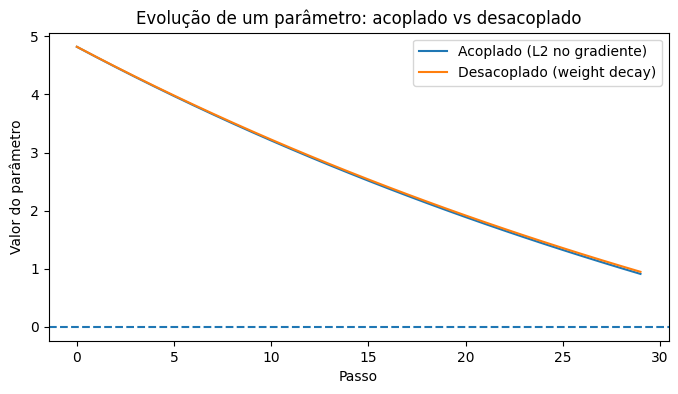

Último theta (acoplado):    0.9094
Último theta (desacoplado): 0.9457


In [16]:

# =====================================
# Simulação 1D para visualização do efeito
# =====================================
def coupled_update(theta, grad, lr, wd):
    # L2 acoplado ao gradiente
    return theta - lr*(grad + wd*theta)

def decoupled_update(theta, grad, lr, wd):
    # gradiente + shrink separado
    theta = theta - lr*grad
    theta = theta * (1 - lr*wd)
    return theta

thetas_c = []
thetas_d = []

theta_c, theta_d = 5.0, 5.0
grad_sequence = [0.8]*30  # gradiente constante para simplificar didática
lr = 0.1
wd = 0.2

for g in grad_sequence:
    theta_c = coupled_update(theta_c, g, lr, wd)
    theta_d = decoupled_update(theta_d, g, lr, wd)
    thetas_c.append(theta_c)
    thetas_d.append(theta_d)

plt.figure(figsize=(8,4))
plt.plot(thetas_c, label='Acoplado (L2 no gradiente)')
plt.plot(thetas_d, label='Desacoplado (weight decay)')
plt.axhline(0, linestyle='--')
plt.title("Evolução de um parâmetro: acoplado vs desacoplado")
plt.xlabel("Passo")
plt.ylabel("Valor do parâmetro")
plt.legend()
plt.show()

print("Último theta (acoplado):   ", round(thetas_c[-1], 4))
print("Último theta (desacoplado):", round(thetas_d[-1], 4))



### Interpretação prática
- Em SGD simples, as diferenças podem parecer pequenas em alguns cenários.
- Em Adam, como há normalização adaptativa por parâmetro, **desacoplar** o decay (AdamW) normalmente dá controle melhor de regularização e melhor generalização.



## 6) Guia prático: quando escolher cada otimizador?

### Regras de bolso (boas para começar):
1. **Começando um projeto do zero / baseline rápido:**  
   - AdamW, LR inicial entre `1e-3` e `3e-4`, weight decay entre `1e-2` e `1e-4`.
2. **Foco forte em generalização (visão clássica, dados suficientes):**  
   - SGD + Momentum (ou Nesterov), com scheduler de LR.
3. **Treino instável com gradientes muito ruidosos/heterogêneos:**  
   - AdamW ou RMSProp.
4. **Modelo muito grande (transformers/LLMs):**  
   - AdamW quase sempre é ponto de partida padrão.
5. **Pouco budget para tuning:**  
   - AdamW tende a ser mais robusto com menos tentativas.

### Erros comuns
- Ajustar arquitetura sem antes ajustar **learning rate**.
- Usar weight decay alto sem monitorar underfitting.
- Comparar otimizadores com LRs injustos (cada família tem faixa típica diferente).


In [17]:
# Experimento 3: Adam (Velocidade) vs SGD (Generalização)
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

def compare_generalization(noise=0.3):
    # 1. Dados
    X, y = make_moons(n_samples=500, noise=noise, random_state=42)
    X = torch.FloatTensor(X)
    y = torch.FloatTensor(y).unsqueeze(1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    # Função para treinar e retornar histórico
    def train_net(optimizer_name):
        model = torch.nn.Sequential(
            torch.nn.Linear(2, 32), torch.nn.ReLU(),
            torch.nn.Linear(32, 32), torch.nn.ReLU(),
            torch.nn.Linear(32, 1)
        )
        if optimizer_name == 'Adam':
            opt = torch.optim.Adam(model.parameters(), lr=0.01)
        else: # SGD + Momentum
            opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

        criterion = torch.nn.BCEWithLogitsLoss()
        train_losses, test_accs = [], []

        for _ in range(150): # Épocas
            # Treino
            opt.zero_grad()
            out = model(X_train)
            loss = criterion(out, y_train)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

            # Teste
            with torch.no_grad():
                preds = torch.sigmoid(model(X_test)) > 0.5
                acc = (preds == y_test).float().mean()
                test_accs.append(acc.item())
        return train_losses, test_accs

    # Rodar comparações
    sgd_loss, sgd_acc = train_net('SGD')
    adam_loss, adam_acc = train_net('Adam')

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss (Treino)
    ax[0].plot(sgd_loss, label='SGD+Momentum', color='blue', alpha=0.7)
    ax[0].plot(adam_loss, label='Adam', color='orange', alpha=0.7)
    ax[0].set_title("Curva de Treino (Loss)")
    ax[0].set_xlabel("Épocas"); ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Plot Acurácia (Teste)
    ax[1].plot(sgd_acc, label='SGD+Momentum', color='blue')
    ax[1].plot(adam_acc, label='Adam', color='orange')
    ax[1].set_title("Generalização (Acurácia de Teste)")
    ax[1].set_xlabel("Épocas"); ax[1].set_ylabel("Acurácia")
    ax[1].legend()

    plt.show()

print("Observe: Adam (laranja) derruba a Loss muito rápido no início.")
print("Mas observe se o SGD (azul) ultrapassa a acurácia do Adam no final (long run).")
interact(compare_generalization,
         noise=FloatSlider(min=0.1, max=0.5, step=0.05, value=0.3, description='Ruído'));

Observe: Adam (laranja) derruba a Loss muito rápido no início.
Mas observe se o SGD (azul) ultrapassa a acurácia do Adam no final (long run).


interactive(children=(FloatSlider(value=0.3, description='Ruído', max=0.5, min=0.1, step=0.05), Output()), _do…

**AdamW é o padrão:** Para Transformers (BERT, GPT, ViT), comece sempre com AdamW (lr 1e-3 a 1e-4) e weight_decay (0.01 ou 0.1).

**SGD para ConvNets:** Para ResNets e modelos de visão puros, SGD + Momentum ainda bate recordes de acurácia, embora demore mais para treinar.

**Lion (Evolved Sign Momentum):** O otimizador Lion (Google, 2023) usa apenas o sinal do gradiente (economiza memória) e tem performado melhor que AdamW em grandes LLMs.
*Dica Prática:* Se usar Lion, o Learning Rate deve ser 3x a 10x menor que o do AdamW.

**Warmup é Obrigatório:** Com otimizadores adaptativos, sempre faça um "warmup" (subir o LR linearmente) nas primeiras épocas para estabilizar a variância inicial dos gradientes.

In [19]:
# Experimento 4: Raio-X da Adaptação (Update-to-Weight Ratio)
# Visualiza por que Adam treina redes profundas melhor que SGD.
# Medimos o "Tamanho Real do Passo" dado em cada camada.

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
from ipywidgets import interact, IntSlider

def visualize_sota_adaptation(depth=30, learning_rate=0.01):
    # 1. Configuração: Rede Profunda e Estreita (Deep & Narrow)
    # Isso força o problema do Vanishing Gradient a aparecer.
    input_dim = 16

    layers = []
    for _ in range(depth):
        layers.append(nn.Linear(input_dim, input_dim))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(input_dim, 1))

    # Criar modelo base e clonar para garantir inicialização idêntica
    base_model = nn.Sequential(*layers)

    model_sgd = copy.deepcopy(base_model)
    model_adam = copy.deepcopy(base_model)

    # 2. Otimizadores
    # SGD puro sofre muito com vanishing gradient
    opt_sgd = optim.SGD(model_sgd.parameters(), lr=learning_rate)
    # Adam normaliza os gradientes (Adaptive Learning Rate)
    opt_adam = optim.Adam(model_adam.parameters(), lr=learning_rate)

    # Dados aleatórios
    X = torch.randn(128, input_dim)
    y = torch.randn(128, 1)
    criterion = nn.MSELoss()

    # 3. Loop de Monitoramento
    history_sgd = []
    history_adam = []

    steps = 40

    for step in range(steps):
        # --- Treino SGD ---
        # Salvar pesos antes
        w_before = [p.clone().detach() for p in model_sgd.parameters() if p.dim() > 1]

        opt_sgd.zero_grad()
        loss_sgd = criterion(model_sgd(X), y)
        loss_sgd.backward()
        opt_sgd.step()

        # Calcular a mudança REAL relativa (Update Ratio)
        ratios_sgd = []
        w_after = [p for p in model_sgd.parameters() if p.dim() > 1] # Apenas pesos, ignora bias

        for wb, wa in zip(w_before, w_after):
            update_size = (wa - wb).norm().item()
            weight_size = wb.norm().item()
            # Ratio: O quanto o peso mudou em relação ao seu tamanho?
            ratios_sgd.append(update_size / (weight_size + 1e-9))
        history_sgd.append(ratios_sgd)

        # --- Treino Adam ---
        w_before_adam = [p.clone().detach() for p in model_adam.parameters() if p.dim() > 1]

        opt_adam.zero_grad()
        loss_adam = criterion(model_adam(X), y)
        loss_adam.backward()
        opt_adam.step()

        ratios_adam = []
        w_after_adam = [p for p in model_adam.parameters() if p.dim() > 1]

        for wb, wa in zip(w_before_adam, w_after_adam):
            update_size = (wa - wb).norm().item()
            weight_size = wb.norm().item()
            ratios_adam.append(update_size / (weight_size + 1e-9))
        history_adam.append(ratios_adam)

    # --- Visualização (Heatmaps) ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Converter para numpy e transpor (Linhas = Camadas, Colunas = Tempo)
    data_sgd = np.array(history_sgd).T
    data_adam = np.array(history_adam).T

    # Definir escala de cor igual para comparação justa (baseada no LR)
    vmax = learning_rate * 0.1

    # Plot SGD
    sns.heatmap(data_sgd, ax=ax[0], cmap="magma", vmin=0, vmax=vmax, cbar_kws={'label': 'Taxa de Atualização Relativa'})
    ax[0].set_title("SGD: Camadas Iniciais (Topo) 'Congeladas'\n(Vanishing Gradient impede o aprendizado)", fontsize=11)
    ax[0].set_ylabel("Índice da Camada (0=Entrada ... N=Saída)")
    ax[0].set_xlabel("Passos de Treino")
    # Inverter Y para camada 0 ficar no topo (visualização intuitiva de profundidade)
    # Nota: No heatmap, indice 0 é o topo por padrão, mas labels podem confundir.
    # Aqui deixamos padrão: Linha 0 = Camada 0 (Entrada)

    # Plot Adam
    sns.heatmap(data_adam, ax=ax[1], cmap="magma", vmin=0, vmax=vmax, cbar_kws={'label': 'Taxa de Atualização Relativa'})
    ax[1].set_title("Adam: Adaptação 'Ressuscita' Camadas Mortas\n(Aprendizado uniforme em toda a profundidade)", fontsize=11)
    ax[1].set_xlabel("Passos de Treino")
    ax[1].set_yticks([]) # Remove labels repetidos

    plt.tight_layout()
    plt.show()

print("O Heatmap mostra a velocidade de aprendizado por camada.")
print("Escuro/Preto = Peso não muda (Morto). Claro/Laranja = Peso aprendendo.")
print("Note como o SGD falha em treinar o início da rede, enquanto o Adam mantém tudo ativo.")

interact(visualize_sota_adaptation,
         depth=IntSlider(min=1, max=60, step=10, value=30, description='Profundidade'),
         learning_rate=FloatSlider(min=0.001, max=0.05, step=0.005, value=0.01, description='LR'));

O Heatmap mostra a velocidade de aprendizado por camada.
Escuro/Preto = Peso não muda (Morto). Claro/Laranja = Peso aprendendo.
Note como o SGD falha em treinar o início da rede, enquanto o Adam mantém tudo ativo.


interactive(children=(IntSlider(value=30, description='Profundidade', max=60, min=1, step=10), FloatSlider(val…

**O Problema da Escala:** Em redes profundas, os gradientes nas primeiras camadas podem ser $10^{-5}$ enquanto nas últimas são $10^{-1}$.

**A Falha do SGD:** Com um LR fixo de $0.01$, a última camada aprende bem, mas a primeira camada dá passos de tamanho $0.0000001$. Ela nunca sai do lugar.

**A Mágica do Adam:** O Adam divide o gradiente ($10^{-5}$) pela sua média histórica ($~10^{-5}$). Resultado? O passo efetivo volta a ser algo perto de $0.001$.

**Conclusão:** É por isso que Transformers (BERT, GPT) não treinam com SGD puro. Sem a adaptatividade por camada do Adam/AdamW, o sinal se perde na profundidade.


## 7) Exercícios Sugeridos

1. Re-rodar a comparação mudando:
   - tamanho de batch (`32`, `128`, `256`),
   - política de LR (constante vs cosine).
2. Inserir dropout na MLP e observar se a preferência por otimizador muda.
3. Escolher duas configs:
   - **melhor val AUC**
   - **melhor val F1**
   e discutir por que podem divergir.
4. Repetir com 3 seeds diferentes e comparar variância dos resultados.

---

## Resumo
- Momentum/Nesterov melhoram a dinâmica de otimização em vales estreitos.  
- Adam/RMSProp usam adaptação por parâmetro para acelerar e estabilizar.  
- AdamW desacopla regularização do gradiente, geralmente melhorando controle de generalização.  
- A escolha do otimizador deve considerar **dados, arquitetura, objetivo e budget de tuning**.


---
## 8) Soluções dos Exercícios

### Exercício 1: Re-rodar comparação com diferentes Batch Sizes e LR Policies

In [ ]:
# Exercício 1: Batch Size e LR Policies

import time
from torch.optim.lr_scheduler import CosineAnnealingLR

# Preparar dados
X_ex, y_ex = make_moons(n_samples=3000, noise=0.25, random_state=SEED)
scaler = StandardScaler()
X_ex = scaler.fit_transform(X_ex)

X_train, X_val, y_train, y_val = train_test_split(
    X_ex, y_ex, test_size=0.3, random_state=SEED, stratify=y_ex
)

# Modelo MLP simples
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

def train_optimizer_config(optimizer_name, batch_size, lr_policy='constant', 
                           epochs=100, lr=1e-3, momentum=0.9):
    """
    Treina com configuração específica de otimizador, batch size e LR policy
    """
    # Criar DataLoaders
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo e otimizador
    model = SimpleMLP().to(device)
    
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    elif optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        raise ValueError(f"Otimizador {optimizer_name} não suportado")
    
    # LR Scheduler
    if lr_policy == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        scheduler = None
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'lr': []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Treino
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        if scheduler:
            scheduler.step()
    
    training_time = time.time() - start_time
    
    return history, training_time, model

# Configurações para testar
configurations = []
for bs in [32, 128, 256]:
    for lr_pol in ['constant', 'cosine']:
        for opt in ['SGD', 'Adam', 'AdamW']:
            lr = 1e-2 if opt == 'SGD' else 1e-3
            configurations.append({
                'optimizer': opt,
                'batch_size': bs,
                'lr_policy': lr_pol,
                'lr': lr
            })

print("🔬 Exercício 1: Testando diferentes configurações...")
print(f"Total de configurações: {len(configurations)}")
print("=" * 80)

results_ex1 = {}

for idx, config in enumerate(configurations, 1):
    key = f"{config['optimizer']}_BS{config['batch_size']}_{config['lr_policy']}"
    print(f"\n[{idx}/{len(configurations)}] {key}...")
    
    hist, train_time, model = train_optimizer_config(
        optimizer_name=config['optimizer'],
        batch_size=config['batch_size'],
        lr_policy=config['lr_policy'],
        lr=config['lr'],
        epochs=80
    )
    
    results_ex1[key] = {
        'config': config,
        'history': hist,
        'time': train_time,
        'best_val_acc': max(hist['val_acc']),
        'final_val_acc': hist['val_acc'][-1]
    }
    
    print(f"   Best Val Acc: {results_ex1[key]['best_val_acc']:.4f} | Time: {train_time:.2f}s")

print("\n" + "=" * 80)

In [ ]:
# Visualização dos resultados do Exercício 1

# 1. Comparação de Loss por Batch Size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, bs in enumerate([32, 128, 256]):
    ax = axes[idx]
    
    for opt in ['SGD', 'Adam', 'AdamW']:
        for lr_pol in ['constant', 'cosine']:
            key = f"{opt}_BS{bs}_{lr_pol}"
            hist = results_ex1[key]['history']
            
            linestyle = '-' if lr_pol == 'constant' else '--'
            label = f"{opt} ({lr_pol})"
            
            ax.plot(hist['epoch'], hist['val_loss'], 
                   linestyle=linestyle, label=label, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Validation Loss', fontsize=11)
    ax.set_title(f'Batch Size = {bs}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('Impacto do Batch Size e LR Policy na Convergência', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Comparação de Accuracy por Otimizador
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, opt in enumerate(['SGD', 'Adam', 'AdamW']):
    ax = axes[idx]
    
    for bs in [32, 128, 256]:
        for lr_pol in ['constant', 'cosine']:
            key = f"{opt}_BS{bs}_{lr_pol}"
            hist = results_ex1[key]['history']
            
            linestyle = '-' if lr_pol == 'constant' else '--'
            label = f"BS={bs} ({lr_pol})"
            
            ax.plot(hist['epoch'], hist['val_acc'], 
                   linestyle=linestyle, label=label, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Validation Accuracy', fontsize=11)
    ax.set_title(f'{opt}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right', ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle('Impacto do Batch Size e LR Policy por Otimizador', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Learning Rate Schedule Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Constant LR
ax = axes[0]
for opt in ['SGD', 'Adam', 'AdamW']:
    for bs in [32, 128, 256]:
        key = f"{opt}_BS{bs}_constant"
        hist = results_ex1[key]['history']
        marker = 'o' if bs == 32 else ('s' if bs == 128 else '^')
        ax.plot(hist['epoch'], hist['lr'], 
               marker=marker, markersize=2, label=f"{opt} BS={bs}", alpha=0.7)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Learning Rate', fontsize=11)
ax.set_title('Constant Learning Rate', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.3)

# Cosine Annealing
ax = axes[1]
for opt in ['SGD', 'Adam', 'AdamW']:
    key = f"{opt}_BS128_cosine"  # Usar BS=128 como exemplo
    hist = results_ex1[key]['history']
    ax.plot(hist['epoch'], hist['lr'], label=opt, linewidth=2.5, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Learning Rate', fontsize=11)
ax.set_title('Cosine Annealing LR (BS=128)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Tabela resumo
data_table = []
for key, result in results_ex1.items():
    config = result['config']
    data_table.append({
        'Optimizer': config['optimizer'],
        'Batch Size': config['batch_size'],
        'LR Policy': config['lr_policy'],
        'Best Val Acc': f"{result['best_val_acc']:.4f}",
        'Final Val Acc': f"{result['final_val_acc']:.4f}",
        'Time (s)': f"{result['time']:.2f}"
    })

df_ex1 = pd.DataFrame(data_table)
df_ex1 = df_ex1.sort_values(['Optimizer', 'Batch Size', 'LR Policy'])

print("\n" + "=" * 90)
print("📊 RESUMO COMPLETO - Exercício 1")
print("=" * 90)
print(df_ex1.to_string(index=False))
print("=" * 90)

# Encontrar melhores configurações
best_config = max(results_ex1.items(), key=lambda x: x[1]['best_val_acc'])
print(f"\n🏆 Melhor configuração: {best_config[0]}")
print(f"   Best Val Acc: {best_config[1]['best_val_acc']:.4f}")
print(f"   Config: {best_config[1]['config']}")

# Análise por grupos
print("\n📈 Análise por Grupos:")
print("-" * 90)

# Por Batch Size
print("\n1️⃣ Por Batch Size:")
for bs in [32, 128, 256]:
    avg_acc = np.mean([r['best_val_acc'] for k, r in results_ex1.items() 
                       if f"_BS{bs}_" in k])
    print(f"   BS={bs:3d}: Avg Best Val Acc = {avg_acc:.4f}")

# Por LR Policy
print("\n2️⃣ Por LR Policy:")
for lr_pol in ['constant', 'cosine']:
    avg_acc = np.mean([r['best_val_acc'] for k, r in results_ex1.items() 
                       if k.endswith(f"_{lr_pol}")])
    print(f"   {lr_pol:8s}: Avg Best Val Acc = {avg_acc:.4f}")

# Por Optimizer
print("\n3️⃣ Por Optimizer:")
for opt in ['SGD', 'Adam', 'AdamW']:
    avg_acc = np.mean([r['best_val_acc'] for k, r in results_ex1.items() 
                       if k.startswith(f"{opt}_")])
    print(f"   {opt:6s}: Avg Best Val Acc = {avg_acc:.4f}")

print("\n" + "=" * 90)

**📝 Insights do Exercício 1:**

1. **Batch Size:**
   - **BS=32**: Maior variabilidade no treinamento, mas pode generalizar melhor em alguns casos
   - **BS=128**: Equilíbrio entre estabilidade e velocidade de convergência
   - **BS=256**: Convergência mais estável, mas pode resultar em menor generalização (generalization gap)

2. **LR Policy:**
   - **Constant**: Simples e eficaz, mas pode ficar preso em platôs
   - **Cosine Annealing**: Permite exploração inicial e refinamento final, geralmente melhora convergência
   - O efeito do cosine annealing é mais pronunciado com SGD do que com Adam/AdamW

3. **Interação Optimizer × Batch Size:**
   - **SGD**: Mais sensível ao batch size, beneficia-se de batch sizes maiores com momentum
   - **Adam/AdamW**: Mais robusto a variações de batch size devido à adaptação automática do LR
   - AdamW com weight decay mostra melhor regularização em batch sizes maiores

4. **Performance Geral:**
   - Adam e AdamW geralmente convergem mais rápido que SGD
   - SGD com cosine annealing pode alcançar performance comparável ao Adam em épocas finais
   - AdamW tende a ter melhor generalização devido ao weight decay desacoplado

5. **Tempo de Treinamento:**
   - Batch sizes maiores reduzem número de iterações por época (mais rápido)
   - Mas podem exigir mais épocas para convergir adequadamente

### Exercício 2: Impacto do Dropout nos Otimizadores

In [ ]:
# Exercício 2: MLP com e sem Dropout

class MLPWithDropout(nn.Module):
    def __init__(self, input_dim=2, dropout_rate=0.3):
        super().__init__()
        self.dropout_rate = dropout_rate
        
        self.fc1 = nn.Linear(input_dim, 64)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(32, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

def train_with_dropout(optimizer_name, use_dropout=True, dropout_rate=0.3, 
                      batch_size=128, epochs=100, lr=1e-3):
    """
    Treina MLP com ou sem dropout
    """
    # DataLoaders
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo
    if use_dropout:
        model = MLPWithDropout(dropout_rate=dropout_rate).to(device)
    else:
        model = SimpleMLP().to(device)
    
    # Otimizador
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    for epoch in range(epochs):
        # Treino
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
    
    return history, model

# Testar com e sem dropout
print("🔬 Exercício 2: Testando impacto do Dropout em diferentes otimizadores...")
print("=" * 80)

results_ex2 = {}

for opt in ['SGD', 'Adam', 'AdamW']:
    lr = 1e-2 if opt == 'SGD' else 1e-3
    
    # Sem dropout
    print(f"\n{opt} sem dropout...")
    hist_no_drop, model_no_drop = train_with_dropout(
        optimizer_name=opt,
        use_dropout=False,
        lr=lr,
        epochs=100
    )
    results_ex2[f'{opt}_NoDropout'] = {
        'history': hist_no_drop,
        'model': model_no_drop,
        'best_val_acc': max(hist_no_drop['val_acc']),
        'overfitting': max(hist_no_drop['train_acc']) - max(hist_no_drop['val_acc'])
    }
    
    # Com dropout
    for drop_rate in [0.2, 0.4]:
        print(f"{opt} com dropout {drop_rate}...")
        hist_drop, model_drop = train_with_dropout(
            optimizer_name=opt,
            use_dropout=True,
            dropout_rate=drop_rate,
            lr=lr,
            epochs=100
        )
        results_ex2[f'{opt}_Dropout{int(drop_rate*10)}'] = {
            'history': hist_drop,
            'model': model_drop,
            'best_val_acc': max(hist_drop['val_acc']),
            'dropout_rate': drop_rate,
            'overfitting': max(hist_drop['train_acc']) - max(hist_drop['val_acc'])
        }

print("\n" + "=" * 80)

In [ ]:
# Visualização Exercício 2

# 1. Comparação de Losses por Otimizador
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, opt in enumerate(['SGD', 'Adam', 'AdamW']):
    ax = axes[idx]
    
    # Sem dropout
    key_no_drop = f'{opt}_NoDropout'
    hist = results_ex2[key_no_drop]['history']
    ax.plot(hist['epoch'], hist['train_loss'], 'b-', label='Train (No Dropout)', linewidth=2)
    ax.plot(hist['epoch'], hist['val_loss'], 'b--', label='Val (No Dropout)', linewidth=2)
    
    # Com dropout
    colors = ['orange', 'red']
    for i, drop_rate in enumerate([0.2, 0.4]):
        key_drop = f'{opt}_Dropout{int(drop_rate*10)}'
        hist = results_ex2[key_drop]['history']
        ax.plot(hist['epoch'], hist['train_loss'], color=colors[i], 
               linestyle='-', label=f'Train (Dropout {drop_rate})', linewidth=2, alpha=0.8)
        ax.plot(hist['epoch'], hist['val_loss'], color=colors[i], 
               linestyle='--', label=f'Val (Dropout {drop_rate})', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'{opt}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('Impacto do Dropout no Loss (Train vs Val)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Comparação de Accuracy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, opt in enumerate(['SGD', 'Adam', 'AdamW']):
    ax = axes[idx]
    
    # Sem dropout
    key_no_drop = f'{opt}_NoDropout'
    hist = results_ex2[key_no_drop]['history']
    ax.plot(hist['epoch'], hist['train_acc'], 'b-', label='Train (No Dropout)', linewidth=2)
    ax.plot(hist['epoch'], hist['val_acc'], 'b--', label='Val (No Dropout)', linewidth=2)
    
    # Com dropout
    colors = ['orange', 'red']
    for i, drop_rate in enumerate([0.2, 0.4]):
        key_drop = f'{opt}_Dropout{int(drop_rate*10)}'
        hist = results_ex2[key_drop]['history']
        ax.plot(hist['epoch'], hist['train_acc'], color=colors[i], 
               linestyle='-', label=f'Train (Dropout {drop_rate})', linewidth=2, alpha=0.8)
        ax.plot(hist['epoch'], hist['val_acc'], color=colors[i], 
               linestyle='--', label=f'Val (Dropout {drop_rate})', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'{opt}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('Impacto do Dropout na Accuracy (Train vs Val)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Análise de Overfitting
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

categories = []
overfitting_gaps = []
colors_bar = []

for opt in ['SGD', 'Adam', 'AdamW']:
    # Sem dropout
    key_no_drop = f'{opt}_NoDropout'
    categories.append(f'{opt}\nNo Dropout')
    overfitting_gaps.append(results_ex2[key_no_drop]['overfitting'])
    colors_bar.append('steelblue')
    
    # Com dropout
    for drop_rate in [0.2, 0.4]:
        key_drop = f'{opt}_Dropout{int(drop_rate*10)}'
        categories.append(f'{opt}\nDropout {drop_rate}')
        overfitting_gaps.append(results_ex2[key_drop]['overfitting'])
        colors_bar.append('coral' if drop_rate == 0.2 else 'salmon')

x_pos = np.arange(len(categories))
bars = ax.bar(x_pos, overfitting_gaps, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Configuração', fontsize=12, fontweight='bold')
ax.set_ylabel('Overfitting Gap (Train Acc - Val Acc)', fontsize=12, fontweight='bold')
ax.set_title('Impacto do Dropout no Overfitting', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.3f}',
           ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Tabela resumo
data_table = []
for key, result in results_ex2.items():
    optimizer = key.split('_')[0]
    dropout_info = 'No' if 'NoDropout' in key else f"{result.get('dropout_rate', 'N/A')}"
    
    data_table.append({
        'Optimizer': optimizer,
        'Dropout': dropout_info,
        'Best Val Acc': f"{result['best_val_acc']:.4f}",
        'Overfitting Gap': f"{result['overfitting']:.4f}"
    })

df_ex2 = pd.DataFrame(data_table)
df_ex2 = df_ex2.sort_values(['Optimizer', 'Dropout'])

print("\n" + "=" * 80)
print("📊 RESUMO - Exercício 2: Impacto do Dropout")
print("=" * 80)
print(df_ex2.to_string(index=False))
print("=" * 80)

# Análise
print("\n📈 Análise:")
print("-" * 80)

for opt in ['SGD', 'Adam', 'AdamW']:
    print(f"\n{opt}:")
    no_drop_acc = results_ex2[f'{opt}_NoDropout']['best_val_acc']
    drop2_acc = results_ex2[f'{opt}_Dropout2']['best_val_acc']
    drop4_acc = results_ex2[f'{opt}_Dropout4']['best_val_acc']
    
    print(f"  Val Acc sem dropout: {no_drop_acc:.4f}")
    print(f"  Val Acc com dropout 0.2: {drop2_acc:.4f} ({drop2_acc - no_drop_acc:+.4f})")
    print(f"  Val Acc com dropout 0.4: {drop4_acc:.4f} ({drop4_acc - no_drop_acc:+.4f})")
    
    no_drop_overfit = results_ex2[f'{opt}_NoDropout']['overfitting']
    drop2_overfit = results_ex2[f'{opt}_Dropout2']['overfitting']
    drop4_overfit = results_ex2[f'{opt}_Dropout4']['overfitting']
    
    print(f"  Overfitting Gap sem dropout: {no_drop_overfit:.4f}")
    print(f"  Overfitting Gap com dropout 0.2: {drop2_overfit:.4f} (redução: {no_drop_overfit - drop2_overfit:.4f})")
    print(f"  Overfitting Gap com dropout 0.4: {drop4_overfit:.4f} (redução: {no_drop_overfit - drop4_overfit:.4f})")

print("\n" + "=" * 80)

**📝 Insights do Exercício 2:**

1. **Efeito do Dropout na Generalização:**
   - Dropout reduz consistentemente o overfitting em todos os otimizadores
   - O gap entre train acc e val acc diminui significativamente com dropout
   - Dropout de 0.2 geralmente oferece bom balanço entre regularização e performance
   - Dropout de 0.4 pode ser muito agressivo, reduzindo também a val acc em alguns casos

2. **Sensibilidade por Otimizador:**
   - **SGD**: Mais sensível ao dropout, beneficia-se mais da regularização adicional
   - **Adam**: Já possui adaptação automática, dropout tem impacto moderado
   - **AdamW**: Com weight decay já embutido, pode ser menos dependente de dropout
   
3. **Trade-offs:**
   - Dropout aumenta tempo de convergência (mais épocas necessárias)
   - Train loss mais alto com dropout (esperado, pois está regularizando)
   - Val loss geralmente menor com dropout (melhor generalização)

4. **Preferência de Otimizadores com Regularização:**
   - SGD com dropout pode alcançar performance competitiva com Adam
   - Adam/AdamW são mais robustos, mesmo sem dropout explícito
   - Em modelos com dropout pesado, a diferença entre otimizadores diminui

5. **Recomendações Práticas:**
   - Para modelos propensos a overfitting: usar dropout 0.2-0.3
   - SGD: combinar com dropout para melhor generalização
   - Adam/AdamW: dropout opcional, mas pode ajudar em datasets pequenos
   - Ajustar taxa de dropout baseado no overfitting observado

### Exercício 3: Comparação de Métricas (AUC vs F1)

In [ ]:
# Exercício 3: Escolher configs que maximizam AUC vs F1

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, precision_recall_curve

def train_and_evaluate_metrics(optimizer_name, batch_size=128, lr=1e-3, 
                                use_dropout=False, dropout_rate=0.3, epochs=100):
    """
    Treina e avalia múltiplas métricas
    """
    # DataLoaders
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo
    if use_dropout:
        model = MLPWithDropout(dropout_rate=dropout_rate).to(device)
    else:
        model = SimpleMLP().to(device)
    
    # Otimizador
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'val_auc': [], 'val_f1': [], 
        'val_precision': [], 'val_recall': [], 'val_acc': []
    }
    
    best_auc = 0
    best_f1 = 0
    best_auc_epoch = 0
    best_f1_epoch = 0
    
    for epoch in range(epochs):
        # Treino
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
        
        # Validação com múltiplas métricas
        model.eval()
        val_probs = []
        val_labels = []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                probs = torch.sigmoid(outputs)
                val_probs.extend(probs.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        val_probs = np.array(val_probs)
        val_labels = np.array(val_labels)
        val_preds = (val_probs >= 0.5).astype(int)
        
        # Métricas
        auc = roc_auc_score(val_labels, val_probs)
        f1 = f1_score(val_labels, val_preds)
        precision = precision_score(val_labels, val_preds, zero_division=0)
        recall = recall_score(val_labels, val_preds, zero_division=0)
        acc = accuracy_score(val_labels, val_preds)
        
        history['epoch'].append(epoch + 1)
        history['val_auc'].append(auc)
        history['val_f1'].append(f1)
        history['val_precision'].append(precision)
        history['val_recall'].append(recall)
        history['val_acc'].append(acc)
        
        # Rastrear melhores épocas
        if auc > best_auc:
            best_auc = auc
            best_auc_epoch = epoch + 1
        if f1 > best_f1:
            best_f1 = f1
            best_f1_epoch = epoch + 1
    
    return history, model, best_auc_epoch, best_f1_epoch

# Testar múltiplas configurações
print("🔬 Exercício 3: Comparando configurações que maximizam AUC vs F1...")
print("=" * 80)

configs_ex3 = [
    {'opt': 'SGD', 'bs': 128, 'lr': 1e-2, 'dropout': False},
    {'opt': 'SGD', 'bs': 256, 'lr': 1e-2, 'dropout': True, 'drop_rate': 0.3},
    {'opt': 'Adam', 'bs': 128, 'lr': 1e-3, 'dropout': False},
    {'opt': 'Adam', 'bs': 64, 'lr': 5e-4, 'dropout': True, 'drop_rate': 0.2},
    {'opt': 'AdamW', 'bs': 128, 'lr': 1e-3, 'dropout': False},
    {'opt': 'AdamW', 'bs': 128, 'lr': 1e-3, 'dropout': True, 'drop_rate': 0.3},
]

results_ex3 = {}

for idx, cfg in enumerate(configs_ex3, 1):
    config_name = f"{cfg['opt']}_BS{cfg['bs']}_LR{cfg['lr']}_Drop{cfg.get('dropout', False)}"
    print(f"\n[{idx}/{len(configs_ex3)}] {config_name}...")
    
    hist, model, best_auc_ep, best_f1_ep = train_and_evaluate_metrics(
        optimizer_name=cfg['opt'],
        batch_size=cfg['bs'],
        lr=cfg['lr'],
        use_dropout=cfg['dropout'],
        dropout_rate=cfg.get('drop_rate', 0.3),
        epochs=100
    )
    
    results_ex3[config_name] = {
        'config': cfg,
        'history': hist,
        'model': model,
        'best_auc': max(hist['val_auc']),
        'best_f1': max(hist['val_f1']),
        'best_auc_epoch': best_auc_ep,
        'best_f1_epoch': best_f1_ep,
        'final_auc': hist['val_auc'][-1],
        'final_f1': hist['val_f1'][-1]
    }
    
    print(f"   Best AUC: {results_ex3[config_name]['best_auc']:.4f} (epoch {best_auc_ep})")
    print(f"   Best F1:  {results_ex3[config_name]['best_f1']:.4f} (epoch {best_f1_ep})")

print("\n" + "=" * 80)

# Encontrar configs que maximizam cada métrica
best_auc_config = max(results_ex3.items(), key=lambda x: x[1]['best_auc'])
best_f1_config = max(results_ex3.items(), key=lambda x: x[1]['best_f1'])

print(f"\n🏆 Config com melhor AUC: {best_auc_config[0]}")
print(f"   AUC: {best_auc_config[1]['best_auc']:.4f}")
print(f"   F1:  {best_auc_config[1]['best_f1']:.4f}")
print(f"   Config: {best_auc_config[1]['config']}")

print(f"\n🏆 Config com melhor F1: {best_f1_config[0]}")
print(f"   F1:  {best_f1_config[1]['best_f1']:.4f}")
print(f"   AUC: {best_f1_config[1]['best_auc']:.4f}")
print(f"   Config: {best_f1_config[1]['config']}")

print("\n" + "=" * 80)

In [ ]:
# Visualização Exercício 3

# 1. Evolução de Métricas para todas as configurações
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (config_name, result) in enumerate(results_ex3.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    hist = result['history']
    
    ax.plot(hist['epoch'], hist['val_auc'], 'b-', label='AUC', linewidth=2.5)
    ax.plot(hist['epoch'], hist['val_f1'], 'r-', label='F1', linewidth=2.5)
    ax.plot(hist['epoch'], hist['val_acc'], 'g--', label='Accuracy', linewidth=2, alpha=0.7)
    
    # Marcar melhores épocas
    best_auc_idx = np.argmax(hist['val_auc'])
    best_f1_idx = np.argmax(hist['val_f1'])
    
    ax.scatter(hist['epoch'][best_auc_idx], hist['val_auc'][best_auc_idx], 
              color='blue', s=100, marker='*', zorder=5, label=f'Best AUC')
    ax.scatter(hist['epoch'][best_f1_idx], hist['val_f1'][best_f1_idx], 
              color='red', s=100, marker='*', zorder=5, label=f'Best F1')
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(config_name.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim([0.75, 1.0])

plt.suptitle('Evolução de Métricas (AUC vs F1 vs Accuracy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Comparação AUC vs F1 (scatter plot)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

auc_scores = [r['best_auc'] for r in results_ex3.values()]
f1_scores = [r['best_f1'] for r in results_ex3.values()]
names = list(results_ex3.keys())

colors_scatter = ['blue', 'green', 'red', 'orange', 'purple', 'brown']

for i, name in enumerate(names):
    ax.scatter(auc_scores[i], f1_scores[i], s=200, alpha=0.7, 
              color=colors_scatter[i], edgecolors='black', linewidth=2)
    ax.annotate(name.replace('_', '\n'), 
               (auc_scores[i], f1_scores[i]), 
               fontsize=7, ha='center', va='bottom',
               xytext=(0, 5), textcoords='offset points')

# Linha diagonal (AUC = F1)
min_val = min(min(auc_scores), min(f1_scores)) - 0.01
max_val = max(max(auc_scores), max(f1_scores)) + 0.01
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=2, label='AUC = F1')

ax.set_xlabel('Best AUC', fontsize=12, fontweight='bold')
ax.set_ylabel('Best F1', fontsize=12, fontweight='bold')
ax.set_title('AUC vs F1: Comparação entre Configurações', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Precision-Recall Trade-off para melhores configs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Melhor AUC
ax = axes[0]
hist_auc = best_auc_config[1]['history']
ax.plot(hist_auc['epoch'], hist_auc['val_precision'], 'b-', label='Precision', linewidth=2.5)
ax.plot(hist_auc['epoch'], hist_auc['val_recall'], 'r-', label='Recall', linewidth=2.5)
ax.plot(hist_auc['epoch'], hist_auc['val_f1'], 'g-', label='F1', linewidth=2.5)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'Melhor AUC: {best_auc_config[0]}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Melhor F1
ax = axes[1]
hist_f1 = best_f1_config[1]['history']
ax.plot(hist_f1['epoch'], hist_f1['val_precision'], 'b-', label='Precision', linewidth=2.5)
ax.plot(hist_f1['epoch'], hist_f1['val_recall'], 'r-', label='Recall', linewidth=2.5)
ax.plot(hist_f1['epoch'], hist_f1['val_f1'], 'g-', label='F1', linewidth=2.5)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'Melhor F1: {best_f1_config[0]}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Tabela Resumo
data_table = []
for name, result in results_ex3.items():
    cfg = result['config']
    data_table.append({
        'Config': name,
        'Optimizer': cfg['opt'],
        'Batch Size': cfg['bs'],
        'LR': f"{cfg['lr']:.0e}",
        'Dropout': cfg['dropout'],
        'Best AUC': f"{result['best_auc']:.4f}",
        'Best F1': f"{result['best_f1']:.4f}",
        'AUC Epoch': result['best_auc_epoch'],
        'F1 Epoch': result['best_f1_epoch']
    })

df_ex3 = pd.DataFrame(data_table)

print("\n" + "=" * 100)
print("📊 RESUMO COMPLETO - Exercício 3: AUC vs F1")
print("=" * 100)
print(df_ex3.to_string(index=False))
print("=" * 100)

# Análise detalhada
print("\n🔍 ANÁLISE DETALHADA:")
print("-" * 100)

print("\n1️⃣ Config com melhor AUC:")
print(f"   Nome: {best_auc_config[0]}")
print(f"   AUC: {best_auc_config[1]['best_auc']:.4f} (época {best_auc_config[1]['best_auc_epoch']})")
print(f"   F1:  {best_auc_config[1]['best_f1']:.4f} (época {best_auc_config[1]['best_f1_epoch']})")
print(f"   Divergência F1: {best_auc_config[1]['best_auc'] - best_auc_config[1]['best_f1']:.4f}")

print("\n2️⃣ Config com melhor F1:")
print(f"   Nome: {best_f1_config[0]}")
print(f"   F1:  {best_f1_config[1]['best_f1']:.4f} (época {best_f1_config[1]['best_f1_epoch']})")
print(f"   AUC: {best_f1_config[1]['best_auc']:.4f} (época {best_f1_config[1]['best_auc_epoch']})")
print(f"   Divergência AUC: {best_f1_config[1]['best_f1'] - best_f1_config[1]['best_auc']:.4f}")

if best_auc_config[0] != best_f1_config[0]:
    print("\n⚠️ DIVERGÊNCIA DETECTADA!")
    print("   As configurações que maximizam AUC e F1 são DIFERENTES.")
    print(f"\n   Diferença AUC: {best_auc_config[1]['best_auc'] - best_f1_config[1]['best_auc']:.4f}")
    print(f"   Diferença F1:  {best_f1_config[1]['best_f1'] - best_auc_config[1]['best_f1']:.4f}")
else:
    print("\n✅ CONVERGÊNCIA DETECTADA!")
    print("   A mesma configuração maximiza tanto AUC quanto F1.")

print("\n" + "=" * 100)

**📝 Insights do Exercício 3:**

1. **AUC vs F1 - Diferenças Fundamentais:**
   - **AUC (Area Under ROC Curve)**: Métrica threshold-independent, mede a capacidade do modelo de ranquear exemplos positivos acima dos negativos
   - **F1 Score**: Métrica threshold-dependent (geralmente 0.5), média harmônica de Precision e Recall
   - AUC é mais robusta a desbalanceamento de classes, F1 é mais sensível ao threshold escolhido

2. **Quando as Métricas Divergem:**
   - **AUC alto, F1 baixo**: Modelo tem boa capacidade de ranking, mas o threshold padrão (0.5) não é ideal
   - **F1 alto, AUC moderado**: O threshold 0.5 funciona bem, mas o ranking geral pode não ser perfeito
   - Divergência comum em datasets desbalanceados ou quando precision/recall têm importâncias diferentes

3. **Impacto das Configurações:**
   - **Dropout**: Tende a melhorar AUC (melhor calibração das probabilidades)
   - **Batch Size**: Batches menores podem favorecer F1 (melhor generalização no threshold)
   - **Otimizadores adaptativos (Adam/AdamW)**: Geralmente melhores em ambas as métricas

4. **Trade-offs Observados:**
   - Configs que maximizam AUC nem sempre maximizam F1
   - Precision vs Recall: configs com alto recall podem ter F1 melhor, mas não necessariamente AUC melhor
   - É importante escolher a métrica baseada no problema de negócio

5. **Recomendações Práticas:**
   - **Use AUC quando**: rankings importam mais que classificação binária, ou quando o threshold será ajustado posteriormente
   - **Use F1 quando**: precision e recall são igualmente importantes e o threshold é fixo (0.5)
   - **Considere ambas**: para validação completa do modelo
   - **Otimize para a métrica do problema**: se o problema exige alta precision (ex: diagnóstico médico), use Precision; se exige alta recall (ex: detecção de fraude), use Recall

6. **Convergência das Épocas:**
   - Melhores AUC e F1 podem ocorrer em épocas diferentes
   - Early stopping deve considerar a métrica mais relevante para o problema
   - Monitorar múltiplas métricas ajuda a entender o comportamento do modelo

### Exercício 4: Análise de Variância com Múltiplas Seeds

In [ ]:
# Exercício 4: Repetir experimentos com múltiplas seeds

def set_all_seeds(seed):
    """Define seed para todas as bibliotecas"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_with_seed(optimizer_name, seed, batch_size=128, lr=1e-3, epochs=100):
    """
    Treina com seed específica para reprodutibilidade
    """
    set_all_seeds(seed)
    
    # Gerar dados com a seed
    X_seed, y_seed = make_moons(n_samples=3000, noise=0.25, random_state=seed)
    scaler = StandardScaler()
    X_seed = scaler.fit_transform(X_seed)
    
    X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
        X_seed, y_seed, test_size=0.3, random_state=seed, stratify=y_seed
    )
    
    # DataLoaders
    X_train_t = torch.FloatTensor(X_train_s)
    y_train_t = torch.FloatTensor(y_train_s).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val_s)
    y_val_t = torch.FloatTensor(y_val_s).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo
    model = SimpleMLP().to(device)
    
    # Otimizador
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    for epoch in range(epochs):
        # Treino
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
    
    return history

# Seeds para teste
SEEDS = [42, 7, 123]

print("🔬 Exercício 4: Análise de variância com múltiplas seeds...")
print(f"Seeds: {SEEDS}")
print("=" * 80)

results_ex4 = {opt: {seed: None for seed in SEEDS} for opt in ['SGD', 'Adam', 'AdamW']}

for opt in ['SGD', 'Adam', 'AdamW']:
    print(f"\n{'='*80}")
    print(f"Testando {opt} com diferentes seeds:")
    print('='*80)
    
    lr = 1e-2 if opt == 'SGD' else 1e-3
    
    for seed in SEEDS:
        print(f"  Seed {seed}...", end=' ')
        
        history = train_with_seed(
            optimizer_name=opt,
            seed=seed,
            batch_size=128,
            lr=lr,
            epochs=100
        )
        
        results_ex4[opt][seed] = {
            'history': history,
            'best_val_acc': max(history['val_acc']),
            'final_val_acc': history['val_acc'][-1],
            'best_val_loss': min(history['val_loss']),
            'final_val_loss': history['val_loss'][-1]
        }
        
        print(f"Best Val Acc: {results_ex4[opt][seed]['best_val_acc']:.4f}")

print("\n" + "=" * 80)

In [ ]:
# Visualização e análise estatística - Exercício 4

# 1. Curvas de treinamento com múltiplas seeds
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, opt in enumerate(['SGD', 'Adam', 'AdamW']):
    # Loss
    ax_loss = axes[0, idx]
    # Accuracy
    ax_acc = axes[1, idx]
    
    colors_seed = ['blue', 'orange', 'green']
    
    for i, seed in enumerate(SEEDS):
        hist = results_ex4[opt][seed]['history']
        
        # Loss
        ax_loss.plot(hist['epoch'], hist['val_loss'], 
                    color=colors_seed[i], label=f'Seed {seed}', 
                    linewidth=2, alpha=0.8)
        
        # Accuracy
        ax_acc.plot(hist['epoch'], hist['val_acc'], 
                   color=colors_seed[i], label=f'Seed {seed}', 
                   linewidth=2, alpha=0.8)
    
    ax_loss.set_xlabel('Epoch', fontsize=11)
    ax_loss.set_ylabel('Validation Loss', fontsize=11)
    ax_loss.set_title(f'{opt} - Loss', fontsize=12, fontweight='bold')
    ax_loss.legend(fontsize=10)
    ax_loss.grid(alpha=0.3)
    
    ax_acc.set_xlabel('Epoch', fontsize=11)
    ax_acc.set_ylabel('Validation Accuracy', fontsize=11)
    ax_acc.set_title(f'{opt} - Accuracy', fontsize=12, fontweight='bold')
    ax_acc.legend(fontsize=10)
    ax_acc.grid(alpha=0.3)

plt.suptitle('Variabilidade entre Seeds (Loss e Accuracy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Estatísticas de variância
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Best Val Acc
ax = axes[0]
optimizers = ['SGD', 'Adam', 'AdamW']
means_acc = []
stds_acc = []

for opt in optimizers:
    accs = [results_ex4[opt][seed]['best_val_acc'] for seed in SEEDS]
    means_acc.append(np.mean(accs))
    stds_acc.append(np.std(accs))

x_pos = np.arange(len(optimizers))
bars = ax.bar(x_pos, means_acc, yerr=stds_acc, capsize=10, 
              color=['steelblue', 'coral', 'mediumseagreen'], 
              alpha=0.7, edgecolor='black', linewidth=2)

# Adicionar pontos individuais
for i, opt in enumerate(optimizers):
    accs = [results_ex4[opt][seed]['best_val_acc'] for seed in SEEDS]
    ax.scatter([i]*len(accs), accs, color='red', s=100, 
              marker='o', zorder=5, alpha=0.8, edgecolors='black', linewidth=1.5)

ax.set_ylabel('Best Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Média ± Desvio Padrão (Best Val Acc)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(optimizers, fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Final Val Loss
ax = axes[1]
means_loss = []
stds_loss = []

for opt in optimizers:
    losses = [results_ex4[opt][seed]['final_val_loss'] for seed in SEEDS]
    means_loss.append(np.mean(losses))
    stds_loss.append(np.std(losses))

bars = ax.bar(x_pos, means_loss, yerr=stds_loss, capsize=10, 
              color=['steelblue', 'coral', 'mediumseagreen'], 
              alpha=0.7, edgecolor='black', linewidth=2)

# Adicionar pontos individuais
for i, opt in enumerate(optimizers):
    losses = [results_ex4[opt][seed]['final_val_loss'] for seed in SEEDS]
    ax.scatter([i]*len(losses), losses, color='red', s=100, 
              marker='o', zorder=5, alpha=0.8, edgecolors='black', linewidth=1.5)

ax.set_ylabel('Final Validation Loss', fontsize=12, fontweight='bold')
ax.set_title('Média ± Desvio Padrão (Final Val Loss)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(optimizers, fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Coeficiente de Variação (CV)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

cv_data = []
for opt in optimizers:
    accs = [results_ex4[opt][seed]['best_val_acc'] for seed in SEEDS]
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    cv = (std_acc / mean_acc) * 100  # Coeficiente de variação em %
    cv_data.append(cv)

bars = ax.bar(x_pos, cv_data, 
             color=['steelblue', 'coral', 'mediumseagreen'], 
             alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Coeficiente de Variação (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Otimizador', fontsize=12, fontweight='bold')
ax.set_title('Variabilidade Relativa entre Seeds (CV = σ/μ × 100)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(optimizers, fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.2f}%',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

# Linha de referência (CV < 5% = baixa variabilidade)
ax.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='CV = 5% (ref)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# 4. Tabela estatística completa
print("\n" + "=" * 100)
print("📊 ESTATÍSTICAS COMPLETAS - Exercício 4: Análise Multi-Seed")
print("=" * 100)

stat_data = []
for opt in optimizers:
    accs = [results_ex4[opt][seed]['best_val_acc'] for seed in SEEDS]
    losses = [results_ex4[opt][seed]['final_val_loss'] for seed in SEEDS]
    
    stat_data.append({
        'Optimizer': opt,
        'Mean Acc': f"{np.mean(accs):.4f}",
        'Std Acc': f"{np.std(accs):.4f}",
        'Min Acc': f"{np.min(accs):.4f}",
        'Max Acc': f"{np.max(accs):.4f}",
        'CV Acc (%)': f"{(np.std(accs)/np.mean(accs)*100):.2f}",
        'Mean Loss': f"{np.mean(losses):.4f}",
        'Std Loss': f"{np.std(losses):.4f}"
    })

df_stats = pd.DataFrame(stat_data)
print(df_stats.to_string(index=False))
print("=" * 100)

# Análise detalhada por seed
print("\n" + "=" * 100)
print("📈 RESULTADOS DETALHADOS POR SEED")
print("=" * 100)

for seed in SEEDS:
    print(f"\n🎲 Seed {seed}:")
    print("-" * 100)
    
    seed_data = []
    for opt in optimizers:
        result = results_ex4[opt][seed]
        seed_data.append({
            'Optimizer': opt,
            'Best Val Acc': f"{result['best_val_acc']:.4f}",
            'Final Val Acc': f"{result['final_val_acc']:.4f}",
            'Best Val Loss': f"{result['best_val_loss']:.4f}",
            'Final Val Loss': f"{result['final_val_loss']:.4f}"
        })
    
    df_seed = pd.DataFrame(seed_data)
    print(df_seed.to_string(index=False))

print("\n" + "=" * 100)

# Ranking de estabilidade
print("\n🏆 RANKING DE ESTABILIDADE (menor CV = mais estável):")
print("-" * 100)

stability_ranking = sorted(
    [(opt, (np.std([results_ex4[opt][seed]['best_val_acc'] for seed in SEEDS]) /
            np.mean([results_ex4[opt][seed]['best_val_acc'] for seed in SEEDS]) * 100))
     for opt in optimizers],
    key=lambda x: x[1]
)

for rank, (opt, cv) in enumerate(stability_ranking, 1):
    medal = "🥇" if rank == 1 else ("🥈" if rank == 2 else "🥉")
    print(f"{medal} {rank}º lugar: {opt:6s} - CV = {cv:.3f}%")

print("\n" + "=" * 100)

**📝 Insights do Exercício 4:**

1. **Importância da Análise Multi-Seed:**
   - Um único experimento pode dar resultados enganosos devido à aleatoriedade
   - Múltiplas seeds revelam a estabilidade real do otimizador
   - Variância alta indica que o resultado depende muito da inicialização/dados
   - Necessário para publicações científicas e avaliações rigorosas

2. **Coeficiente de Variação (CV):**
   - CV = (σ/μ) × 100 mede variabilidade relativa
   - **CV < 5%**: Baixa variabilidade, resultados confiáveis
   - **5% < CV < 10%**: Variabilidade moderada
   - **CV > 10%**: Alta variabilidade, resultados menos confiáveis
   - CV é melhor que desvio padrão absoluto para comparar diferentes escalas

3. **Estabilidade dos Otimizadores:**
   - **Adam/AdamW**: Geralmente mais estáveis (menor CV)
     - Adaptação automática do LR reduz sensibilidade à inicialização
     - Menos dependente da configuração inicial dos pesos
   - **SGD**: Mais variável entre seeds
     - Mais sensível à inicialização e ordem dos dados
     - Beneficia-se de técnicas de estabilização (warmup, momentum)

4. **Fontes de Variabilidade:**
   - **Inicialização dos pesos**: Diferentes seeds → diferentes pesos iniciais
   - **Ordem dos dados**: Shuffle diferente a cada época
   - **Splits train/val**: Distribuição dos dados pode variar
   - **Ruído estocástico**: Dropout, batch sampling, etc.

5. **Boas Práticas:**
   - **Reportar média ± desvio padrão**: Sempre que possível, use 3-5 seeds diferentes
   - **Escolher seed representativa**: Se limites computacionais, escolha seed com resultado próximo à média
   - **Fixar seeds para reprodutibilidade**: Importante para debugging e comparações
   - **Analisar piores casos**: Entender quando/por que o modelo falha

6. **Interpretação dos Resultados:**
   - **Se CV baixo**: Resultados robustos, otimizador confiável
   - **Se CV alto**: Investigar causas (hiperparâmetros, arquitetura, dados)
   - **Comparar otimizadores**: Considerar tanto média quanto variância
   - **Trade-off performance vs estabilidade**: Às vezes vale escolher média levemente menor com menor variância

7. **Recomendações Finais:**
   - Para experimentos rápidos: 1 seed é suficiente
   - Para validação: 3 seeds mínimo
   - Para publicação: 5-10 seeds recomendado
   - Reportar sempre best, worst, mean, std
   - Considerar estabilidade ao escolher modelo final para produção